# Scalar Alpha=1 Branch Probe Results

This notebook keeps focused scalar alpha=1 branch-readout results, shown as short branch-probe story plots for cubic, square, and exponential relations.

## Setup

In [34]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

GLOBAL_SEED = 123
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / "contrastive_encoders").exists():
        module_root = candidate
        break
else:
    raise RuntimeError("Could not find the contrastive_encoders package folder.")

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

PLOT_DIR = module_root / "reports" / "report-plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)



In [35]:
import importlib

import contrastive_encoders
from contrastive_encoders import data, interpretability, plotting, training

for module in [data, interpretability, training, plotting]:
    importlib.reload(module)

importlib.reload(contrastive_encoders)

from contrastive_encoders import (
    TrainConfig,
    deterministic_relation,
    fit_ridge_probe,
    generate_deterministic_relation_dataset,
    predict_ridge_probe,
    set_report_plot_style,
    train_one_model_with_artifacts,
)

set_report_plot_style()


## Helpers

In [36]:
def standardize_like_training(X: np.ndarray, X_train: np.ndarray) -> np.ndarray:
    x_mean = X_train.mean(axis=0, keepdims=True)
    x_scale = X_train.std(axis=0, ddof=1, keepdims=True)
    x_scale = np.where(x_scale > 1e-12, x_scale, 1.0)
    return (X - x_mean) / x_scale


@torch.no_grad()
def branch_components_numpy(model: torch.nn.Module, X_standardized: np.ndarray, device: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if not hasattr(model.encoder_x, "components"):
        raise TypeError("This diagnostic requires a residual encoder with branch components.")
    model.eval()
    X_tensor = torch.tensor(X_standardized, dtype=torch.float32, device=device)
    linear, nonlinear = model.encoder_x.components(X_tensor)
    total = linear + nonlinear
    return (
        linear.detach().cpu().numpy(),
        nonlinear.detach().cpu().numpy(),
        total.detach().cpu().numpy(),
    )


def true_f_values(x_values: np.ndarray, relationship: str) -> np.ndarray:
    x_column = np.asarray(x_values, dtype=float).reshape(-1, 1)
    return deterministic_relation(x_column, q=1, relationship=relationship)[:, 0]


def make_coordinate_sweep(raw_dataset, coordinate: int, sweep_values: np.ndarray, base_observation: int | None = None) -> np.ndarray:
    if base_observation is None:
        X_sweep = np.zeros((len(sweep_values), raw_dataset.X_train.shape[1]))
    else:
        X_sweep = np.repeat(raw_dataset.X_test[[base_observation]], len(sweep_values), axis=0)
    X_sweep[:, coordinate] = sweep_values
    return X_sweep


def save_current_figure(fig: plt.Figure, filename: str) -> Path:
    path = PLOT_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print("saved", path)
    return path

def branch_only_probe_curve(
    run,
    raw_dataset,
    relationship: str,
    coordinate: int,
    sweep_values: np.ndarray,
    base_observation: int | None = None,
    probe_alpha: float = 1e-3,
    device: str = DEVICE,
) -> pd.DataFrame:
    linear_train, nonlinear_train, total_train = branch_components_numpy(
        run.model,
        run.data.X_train,
        device=device,
    )

    probes = {
        "linear branch only": fit_ridge_probe(linear_train, raw_dataset.Z_y_train, alpha=probe_alpha),
        "nonlinear branch only": fit_ridge_probe(nonlinear_train, raw_dataset.Z_y_train, alpha=probe_alpha),
        "combined embedding": fit_ridge_probe(total_train, raw_dataset.Z_y_train, alpha=probe_alpha),
    }

    X_sweep = make_coordinate_sweep(raw_dataset, coordinate, sweep_values, base_observation=base_observation)
    X_sweep_standardized = standardize_like_training(X_sweep, raw_dataset.X_train)
    linear_sweep, nonlinear_sweep, total_sweep = branch_components_numpy(run.model, X_sweep_standardized, device=device)
    branch_embeddings = {
        "linear branch only": linear_sweep,
        "nonlinear branch only": nonlinear_sweep,
        "combined embedding": total_sweep,
    }

    records = []
    for branch_name, probe in probes.items():
        prediction = predict_ridge_probe(probe, branch_embeddings[branch_name])[:, coordinate]
        records.append(
            pd.DataFrame(
                {
                    "readout": branch_name,
                    "coordinate": coordinate,
                    "x_value": sweep_values,
                    "true_y": true_f_values(sweep_values, relationship),
                    "predicted_y": prediction,
                }
            )
        )

    return pd.concat(records, ignore_index=True)


def plot_branch_only_probe_curve(curves: pd.DataFrame, title: str, filename: str | None = None) -> plt.Figure:
    branch_styles = {
        "linear branch only": {"color": "#0072B2", "linewidth": 3.0, "linestyle": "-"},
        "nonlinear branch only": {"color": "#D55E00", "linewidth": 3.0, "linestyle": "-"},
        "combined embedding": {"color": "#009E73", "linewidth": 3.4, "linestyle": "-"},
    }

    fig, ax = plt.subplots(figsize=(11.5, 7.0))
    true_curve = curves[["x_value", "true_y"]].drop_duplicates().sort_values("x_value")
    ax.plot(
        true_curve["x_value"],
        true_curve["true_y"],
        color="#17212B",
        linewidth=4.2,
        label="true f(x)",
        zorder=4,
    )

    for readout, subset in curves.groupby("readout", sort=False):
        subset = subset.sort_values("x_value")
        style = branch_styles.get(readout, {"linewidth": 2.6})
        ax.plot(
            subset["x_value"],
            subset["predicted_y"],
            label=readout,
            zorder=3,
            **style,
        )

    ax.axhline(0, linestyle=":", color="#667085", linewidth=1.4)
    ax.axvline(0, linestyle=":", color="#667085", linewidth=1.4)
    ax.set_title(title, fontsize=18, fontweight="semibold", pad=14)
    ax.set_xlabel("Swept raw coordinate x_j", fontsize=14)
    ax.set_ylabel("Clean target y_j", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(axis="both", color="#D8DEE9", linewidth=0.9, alpha=0.9)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=True, facecolor="white", edgecolor="#CBD5E1", fontsize=12, loc="upper left")
    fig.tight_layout()
    if filename is not None:
        save_current_figure(fig, filename)
    return fig

def fit_centered_ridge(z_train: np.ndarray, target_train: np.ndarray, alpha: float = 1e-3) -> dict[str, np.ndarray | float]:
    z_mean = z_train.mean(axis=0, keepdims=True)
    target_mean = target_train.mean(axis=0, keepdims=True)
    z_centered = z_train - z_mean
    target_centered = target_train - target_mean
    regularizer = alpha * np.eye(z_centered.shape[1])
    weights = np.linalg.solve(
        z_centered.T @ z_centered + regularizer,
        z_centered.T @ target_centered,
    )
    return {
        "z_mean": z_mean,
        "target_mean": target_mean,
        "weights": weights,
        "alpha": alpha,
    }


def shared_probe_decomposition_curve(
    run,
    raw_dataset,
    relationship: str,
    coordinate: int,
    sweep_values: np.ndarray,
    base_observation: int | None = None,
    probe_alpha: float = 1e-3,
    device: str = DEVICE,
) -> pd.DataFrame:
    linear_train, nonlinear_train, _ = branch_components_numpy(run.model, run.data.X_train, device=device)
    z_train = np.concatenate([linear_train, nonlinear_train], axis=1)
    probe = fit_centered_ridge(z_train, raw_dataset.Z_y_train, alpha=probe_alpha)

    split = linear_train.shape[1]
    linear_mean = probe["z_mean"][:, :split]
    nonlinear_mean = probe["z_mean"][:, split:]
    linear_weights = probe["weights"][:split, :]
    nonlinear_weights = probe["weights"][split:, :]
    target_mean = probe["target_mean"]

    X_sweep = make_coordinate_sweep(raw_dataset, coordinate, sweep_values, base_observation=base_observation)
    X_sweep_standardized = standardize_like_training(X_sweep, raw_dataset.X_train)
    linear_sweep, nonlinear_sweep, _ = branch_components_numpy(run.model, X_sweep_standardized, device=device)

    linear_contribution = (linear_sweep - linear_mean) @ linear_weights
    nonlinear_contribution = (nonlinear_sweep - nonlinear_mean) @ nonlinear_weights
    combined_prediction = target_mean + linear_contribution + nonlinear_contribution

    return pd.DataFrame(
        {
            "coordinate": coordinate,
            "x_value": sweep_values,
            "true_y": true_f_values(sweep_values, relationship),
            "combined_prediction": combined_prediction[:, coordinate],
            "linear_contribution": linear_contribution[:, coordinate],
            "nonlinear_contribution": nonlinear_contribution[:, coordinate],
        }
    )


def plot_shared_probe_decomposition(curves: pd.DataFrame, title: str, filename: str | None = None) -> plt.Figure:
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), sharex=True)
    curves = curves.sort_values("x_value")

    axes[0].plot(curves["x_value"], curves["true_y"], color="#202830", linewidth=2.6, label="true f(x)")
    axes[0].plot(curves["x_value"], curves["combined_prediction"], color="#D95F02", linewidth=2.1, label="shared-probe fhat(x)")
    axes[0].set_title("Combined readout")
    axes[0].set_ylabel("Clean target y_j")
    axes[0].legend()

    axes[1].plot(curves["x_value"], curves["linear_contribution"], linewidth=2.1, label="linear contribution")
    axes[1].plot(curves["x_value"], curves["nonlinear_contribution"], linewidth=2.1, label="nonlinear contribution")
    axes[1].axhline(0, linestyle=":", color="#5C6670", linewidth=1.0)
    axes[1].set_title("Centered branch contributions")
    axes[1].set_ylabel("Contribution to fhat")
    axes[1].legend()

    for ax in axes:
        ax.axvline(0, linestyle=":", color="#5C6670", linewidth=1.0)
        ax.set_xlabel("Swept raw x_j")
        ax.grid(axis="both", alpha=0.75)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(title, y=1.03, fontsize=13, fontweight="semibold")
    if filename is not None:
        save_current_figure(fig, filename)
    return fig


### Branch Probe Story Plot

This view uses solid lines with a soft same-color glow. It shows the two branch readouts together in strong color with their combined embedding faded, then compares the combined readout to the true target, then overlays all four curves.


In [37]:
def branch_plot_colors() -> dict[str, str]:
    return {
        "linear branch only": "#0072B2",
        "nonlinear branch only": "#D55E00",
        "combined embedding": "#009E73",
        "true target": "#17212B",
    }


def padded_limits(values: np.ndarray, fraction: float = 0.12) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    lower = float(np.nanmin(values))
    upper = float(np.nanmax(values))
    span = max(upper - lower, 1e-9)
    return lower - fraction * span, upper + fraction * span


def draw_hued_line(
    ax: plt.Axes,
    x: np.ndarray,
    y: np.ndarray,
    *,
    color: str,
    label: str,
    linewidth: float = 3.0,
    alpha: float = 1.0,
    zorder: int = 3,
    glow: bool = True,
) -> None:
    if glow:
        ax.plot(
            x,
            y,
            color=color,
            linewidth=linewidth + 8.0,
            alpha=0.08 * alpha,
            solid_capstyle="round",
            zorder=zorder - 2,
        )
        ax.plot(
            x,
            y,
            color=color,
            linewidth=linewidth + 4.0,
            alpha=0.14 * alpha,
            solid_capstyle="round",
            zorder=zorder - 1,
        )
    ax.plot(
        x,
        y,
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        label=label,
        solid_capstyle="round",
        zorder=zorder,
    )


def finish_curve_axis(ax: plt.Axes, *, ylabel: str | None = None) -> None:
    ax.axhline(0, linestyle=":", color="#667085", linewidth=1.1)
    ax.axvline(0, linestyle=":", color="#667085", linewidth=1.1)
    ax.set_xlabel("Swept raw coordinate x_j")
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(axis="both", color="#D8DEE9", linewidth=0.9, alpha=0.9)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=11)


def curve_for_readout(curves: pd.DataFrame, readout: str) -> pd.DataFrame:
    return curves.loc[curves["readout"] == readout].sort_values("x_value")


def plot_branch_probe_story(
    curves: pd.DataFrame,
    title_prefix: str,
    filename_prefix: str | None = None,
    target_label: str = "true f(x)",
) -> dict[str, plt.Figure]:
    curves = curves.sort_values(["readout", "x_value"])
    true_curve = curves[["x_value", "true_y"]].drop_duplicates().sort_values("x_value")
    linear_curve = curve_for_readout(curves, "linear branch only")
    nonlinear_curve = curve_for_readout(curves, "nonlinear branch only")
    combined_curve = curve_for_readout(curves, "combined embedding")
    colors = branch_plot_colors()

    x_true = true_curve["x_value"].to_numpy()
    y_true = true_curve["true_y"].to_numpy()
    x_linear = linear_curve["x_value"].to_numpy()
    y_linear = linear_curve["predicted_y"].to_numpy()
    x_nonlinear = nonlinear_curve["x_value"].to_numpy()
    y_nonlinear = nonlinear_curve["predicted_y"].to_numpy()
    x_combined = combined_curve["x_value"].to_numpy()
    y_combined = combined_curve["predicted_y"].to_numpy()

    branch_ylim = padded_limits(np.r_[y_linear, y_nonlinear, y_combined], fraction=0.16)
    target_ylim = padded_limits(np.r_[y_true, y_combined], fraction=0.10)

    fig_branches_together, ax = plt.subplots(figsize=(11.5, 6.6))
    draw_hued_line(
        ax,
        x_combined,
        y_combined,
        color=colors["combined embedding"],
        label="combined embedding",
        linewidth=3.6,
        alpha=0.30,
        zorder=2,
    )
    draw_hued_line(
        ax,
        x_linear,
        y_linear,
        color=colors["linear branch only"],
        label="linear branch only",
        linewidth=3.7,
        alpha=0.98,
        zorder=4,
    )
    draw_hued_line(
        ax,
        x_nonlinear,
        y_nonlinear,
        color=colors["nonlinear branch only"],
        label="nonlinear branch only",
        linewidth=3.7,
        alpha=0.98,
        zorder=4,
    )
    ax.set_ylim(branch_ylim)
    ax.set_title(f"{title_prefix}: branches together", fontsize=17, fontweight="semibold", pad=12)
    finish_curve_axis(ax, ylabel="Probe prediction")
    ax.legend(frameon=True, facecolor="white", edgecolor="#CBD5E1", fontsize=11, loc="upper left")
    fig_branches_together.tight_layout()

    fig_combined, ax = plt.subplots(figsize=(11.5, 6.6))
    draw_hued_line(
        ax,
        x_true,
        y_true,
        color=colors["true target"],
        label=target_label,
        linewidth=4.3,
        glow=False,
        zorder=5,
    )
    draw_hued_line(
        ax,
        x_combined,
        y_combined,
        color=colors["combined embedding"],
        label="combined embedding",
        linewidth=3.8,
        zorder=4,
    )
    ax.set_ylim(target_ylim)
    ax.set_title(f"{title_prefix}: combined readout vs true target", fontsize=17, fontweight="semibold", pad=12)
    finish_curve_axis(ax, ylabel="Clean target y_j")
    ax.legend(frameon=True, facecolor="white", edgecolor="#CBD5E1", fontsize=11, loc="upper left")
    fig_combined.tight_layout()

    fig_all, ax = plt.subplots(figsize=(12.5, 7.0))
    draw_hued_line(
        ax,
        x_linear,
        y_linear,
        color=colors["linear branch only"],
        label="linear branch only",
        linewidth=2.8,
        alpha=0.34,
        zorder=2,
    )
    draw_hued_line(
        ax,
        x_nonlinear,
        y_nonlinear,
        color=colors["nonlinear branch only"],
        label="nonlinear branch only",
        linewidth=2.8,
        alpha=0.34,
        zorder=2,
    )
    draw_hued_line(
        ax,
        x_combined,
        y_combined,
        color=colors["combined embedding"],
        label="combined embedding",
        linewidth=4.0,
        alpha=0.96,
        zorder=4,
    )
    draw_hued_line(
        ax,
        x_true,
        y_true,
        color=colors["true target"],
        label=target_label,
        linewidth=4.4,
        alpha=1.0,
        glow=False,
        zorder=5,
    )
    ax.set_ylim(target_ylim)
    ax.set_title(f"{title_prefix}: all branch probe curves", fontsize=17, fontweight="semibold", pad=12)
    finish_curve_axis(ax, ylabel="Clean target y_j")
    ax.legend(frameon=True, facecolor="white", edgecolor="#CBD5E1", fontsize=11, loc="upper left")
    fig_all.tight_layout()

    if filename_prefix is not None:
        save_current_figure(fig_branches_together, f"{filename_prefix}-branches-together.png")
        save_current_figure(fig_combined, f"{filename_prefix}-combined-vs-target.png")
        save_current_figure(fig_all, f"{filename_prefix}-all-four.png")

    return {
        "branches_together": fig_branches_together,
        "combined_vs_target": fig_combined,
        "all_four": fig_all,
    }


## Train The Scalar Alpha=1 Model

In [38]:
RELATIONSHIP = "cubic"
TARGET_SNR = 20.0
X_STD = 1.5
EPOCHS = 300

scalar_dataset = generate_deterministic_relation_dataset(
    n_train=256,
    n_test=512,
    p=1,
    q=1,
    relationship=RELATIONSHIP,
    target_snr=TARGET_SNR,
    rng=np.random.default_rng(GLOBAL_SEED + 7000),
    x_std=X_STD,
)

alpha1_config = TrainConfig(
    name="MLP nonlinear alpha=1.00",
    architecture="residual",
    hidden_dim=16,
    nonlinear_scale=1.0,
    embedding_dim=4,
    epochs=EPOCHS,
)

scalar_run = train_one_model_with_artifacts(
    dataset=scalar_dataset,
    config=alpha1_config,
    seed=GLOBAL_SEED + 7100,
    device=DEVICE,
)


## Result

saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-cubic-branch-probe-story-branches-together.png
saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-cubic-branch-probe-story-combined-vs-target.png
saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-cubic-branch-probe-story-all-four.png


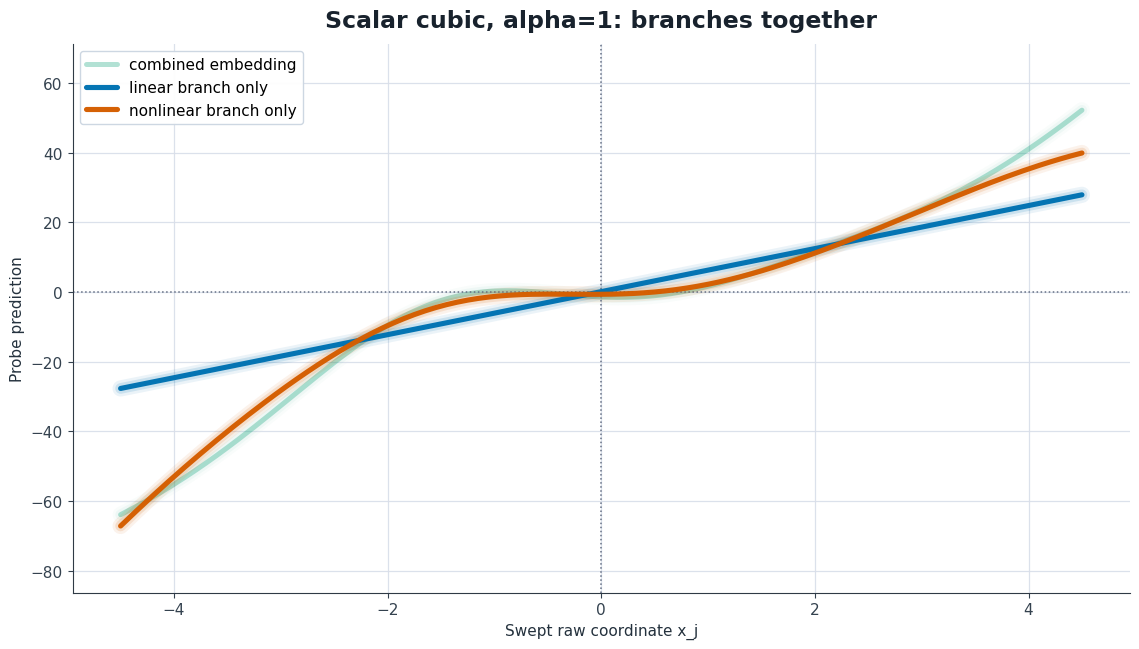

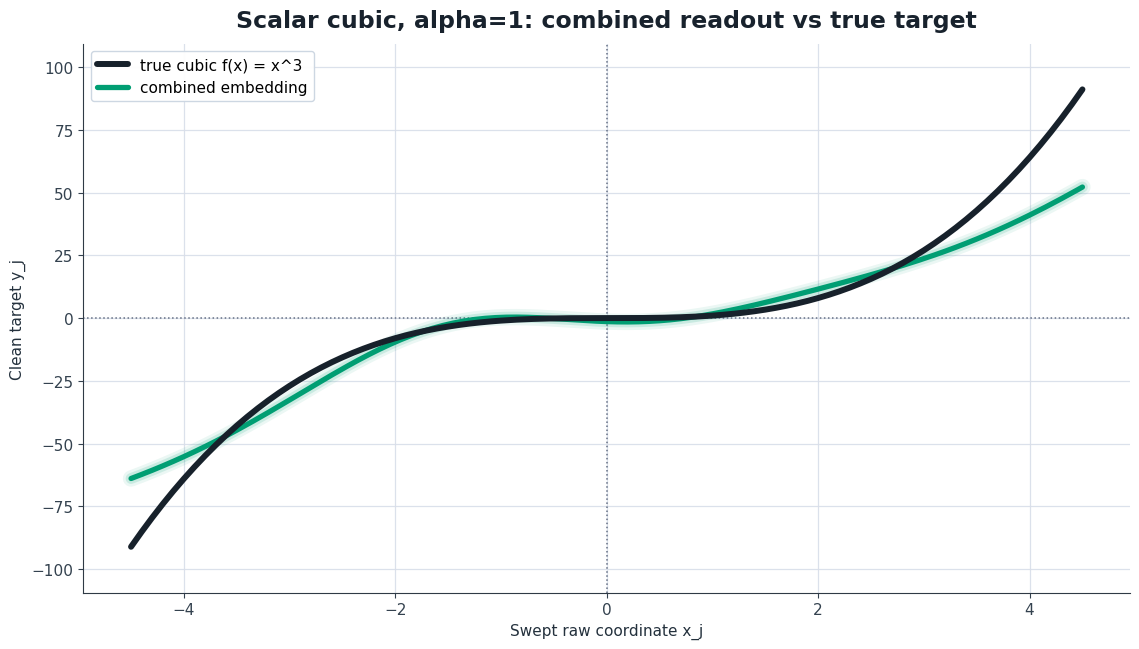

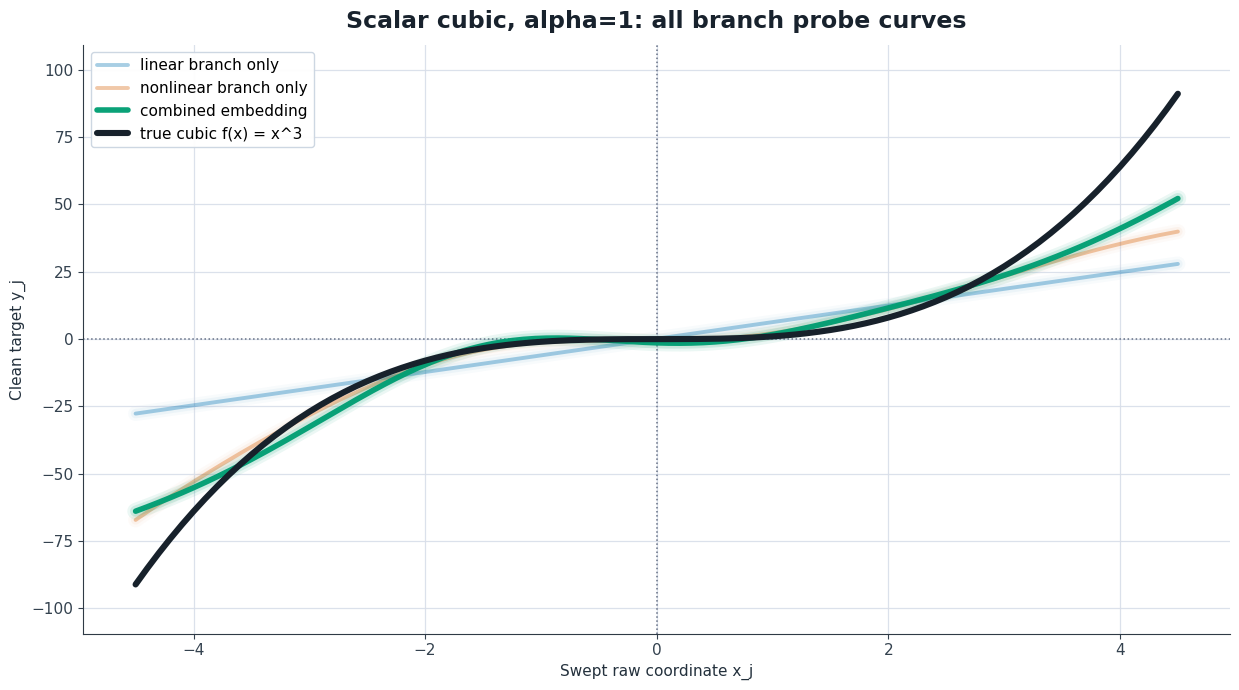

In [39]:
scalar_sweep = np.linspace(-3 * X_STD, 3 * X_STD, 181)

scalar_branch_curves = branch_only_probe_curve(
    run=scalar_run,
    raw_dataset=scalar_dataset,
    relationship=RELATIONSHIP,
    coordinate=0,
    sweep_values=scalar_sweep,
)

branch_story_figures = plot_branch_probe_story(
    scalar_branch_curves,
    title_prefix=f"Scalar {RELATIONSHIP}, alpha=1",
    filename_prefix=f"alpha1-scalar-{RELATIONSHIP}-branch-probe-story",
    target_label="true cubic f(x) = x^3",
)


## Square Relation Alpha=1 Model

This repeats the same scalar setup, but changes the clean target to `y = x^2` by using `relationship="quadratic"`.

In [40]:
SQUARE_RELATIONSHIP = "quadratic"

square_dataset = generate_deterministic_relation_dataset(
    n_train=256,
    n_test=512,
    p=1,
    q=1,
    relationship=SQUARE_RELATIONSHIP,
    target_snr=TARGET_SNR,
    rng=np.random.default_rng(GLOBAL_SEED + 7200),
    x_std=X_STD,
)

square_run = train_one_model_with_artifacts(
    dataset=square_dataset,
    config=alpha1_config,
    seed=GLOBAL_SEED + 7300,
    device=DEVICE,
)


## Square Result

saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-quadratic-branch-probe-story-branches-together.png
saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-quadratic-branch-probe-story-combined-vs-target.png
saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-quadratic-branch-probe-story-all-four.png


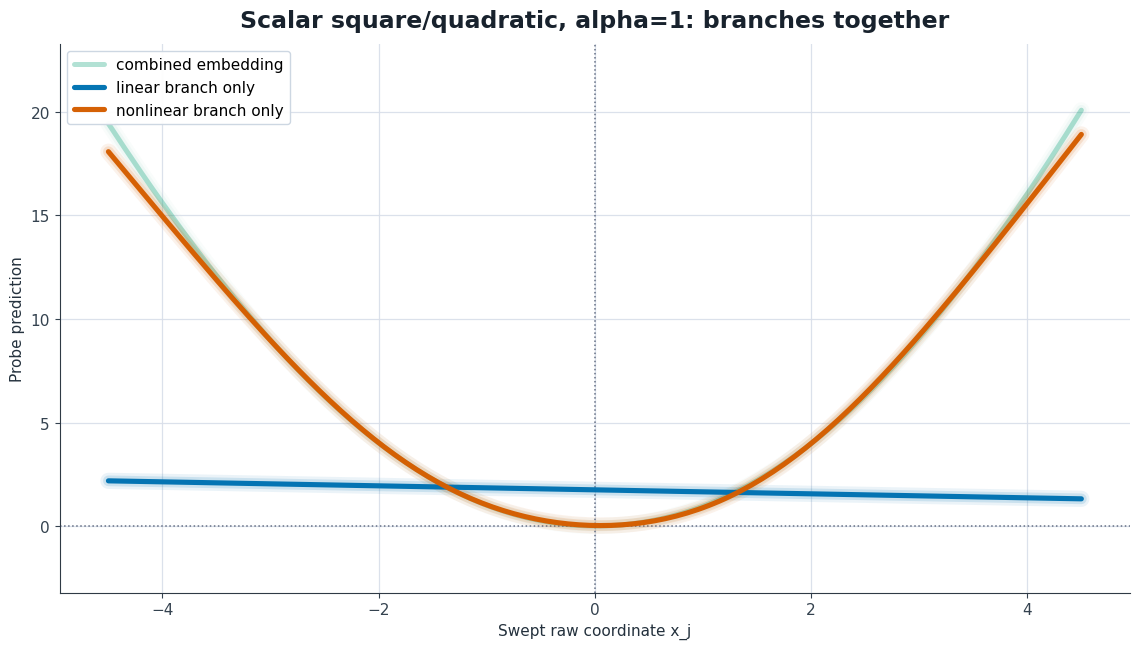

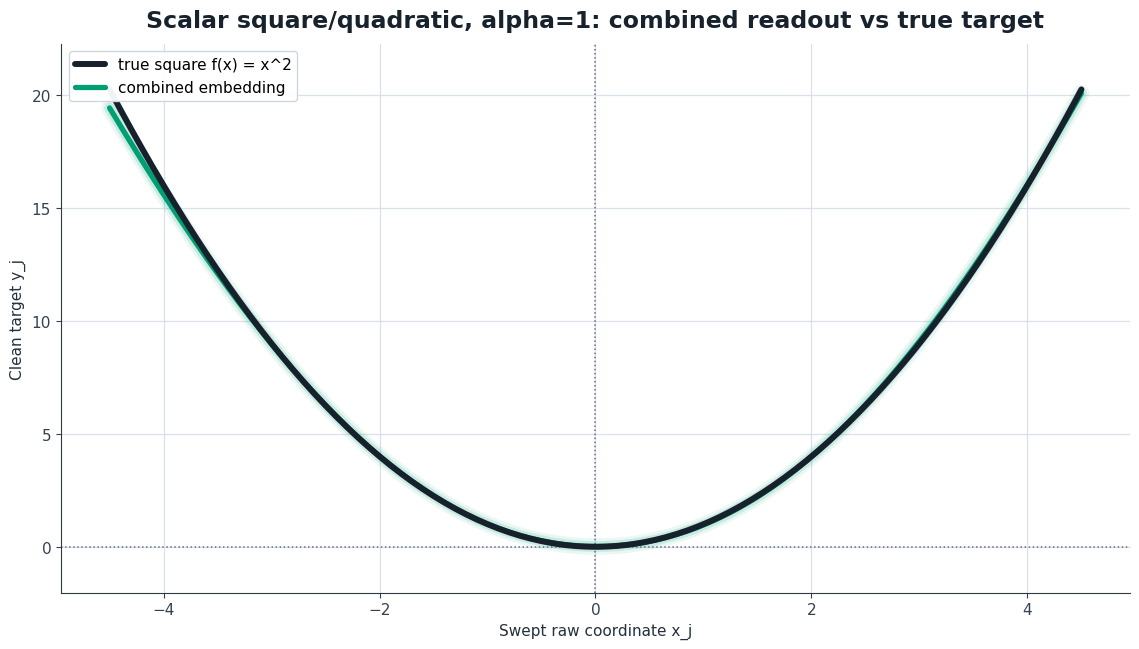

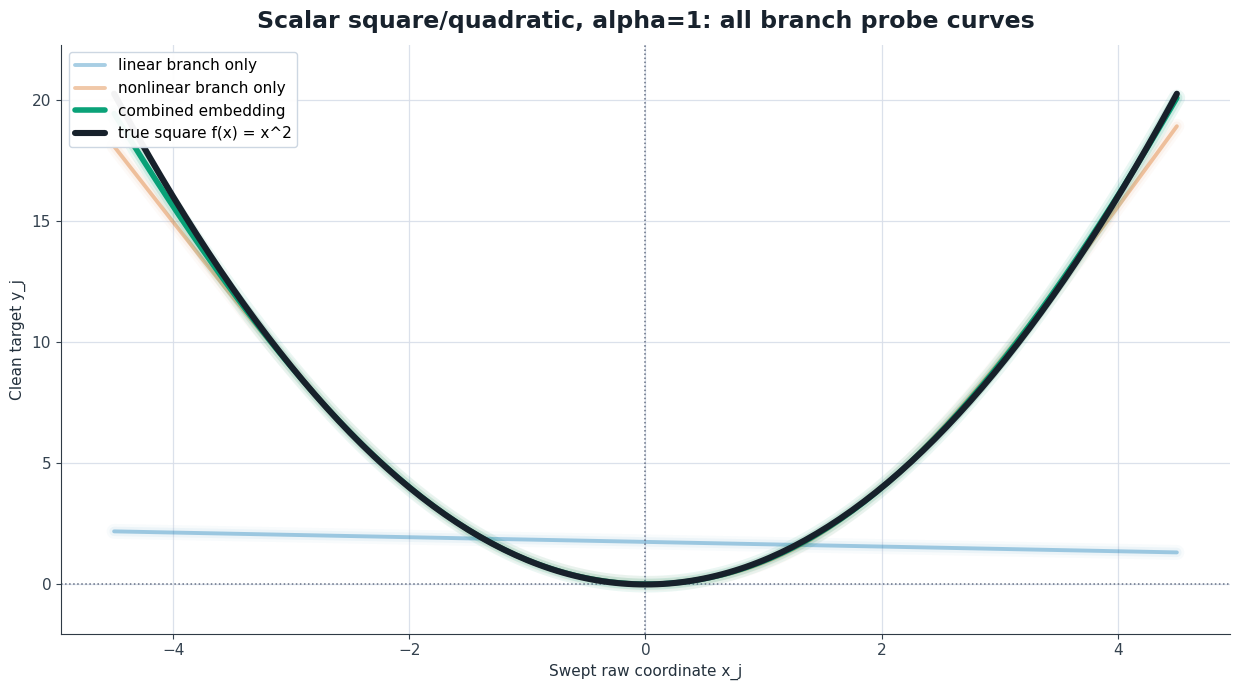

In [41]:
square_sweep = np.linspace(-3 * X_STD, 3 * X_STD, 181)

square_branch_curves = branch_only_probe_curve(
    run=square_run,
    raw_dataset=square_dataset,
    relationship=SQUARE_RELATIONSHIP,
    coordinate=0,
    sweep_values=square_sweep,
)

square_branch_story_figures = plot_branch_probe_story(
    square_branch_curves,
    title_prefix="Scalar square/quadratic, alpha=1",
    filename_prefix=f"alpha1-scalar-{SQUARE_RELATIONSHIP}-branch-probe-story",
    target_label="true square f(x) = x^2",
)


## Exponential Relation Alpha=1 Model

This repeats the same scalar setup again, but changes the clean target to `y = exp(x)` by using `relationship="exponential"`.

In [42]:
EXPONENTIAL_RELATIONSHIP = "exponential"

exponential_dataset = generate_deterministic_relation_dataset(
    n_train=256,
    n_test=512,
    p=1,
    q=1,
    relationship=EXPONENTIAL_RELATIONSHIP,
    target_snr=TARGET_SNR,
    rng=np.random.default_rng(GLOBAL_SEED + 7400),
    x_std=X_STD,
)

exponential_run = train_one_model_with_artifacts(
    dataset=exponential_dataset,
    config=alpha1_config,
    seed=GLOBAL_SEED + 7500,
    device=DEVICE,
)


## Exponential Result

saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-exponential-branch-probe-story-branches-together.png
saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-exponential-branch-probe-story-combined-vs-target.png
saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-exponential-branch-probe-story-all-four.png


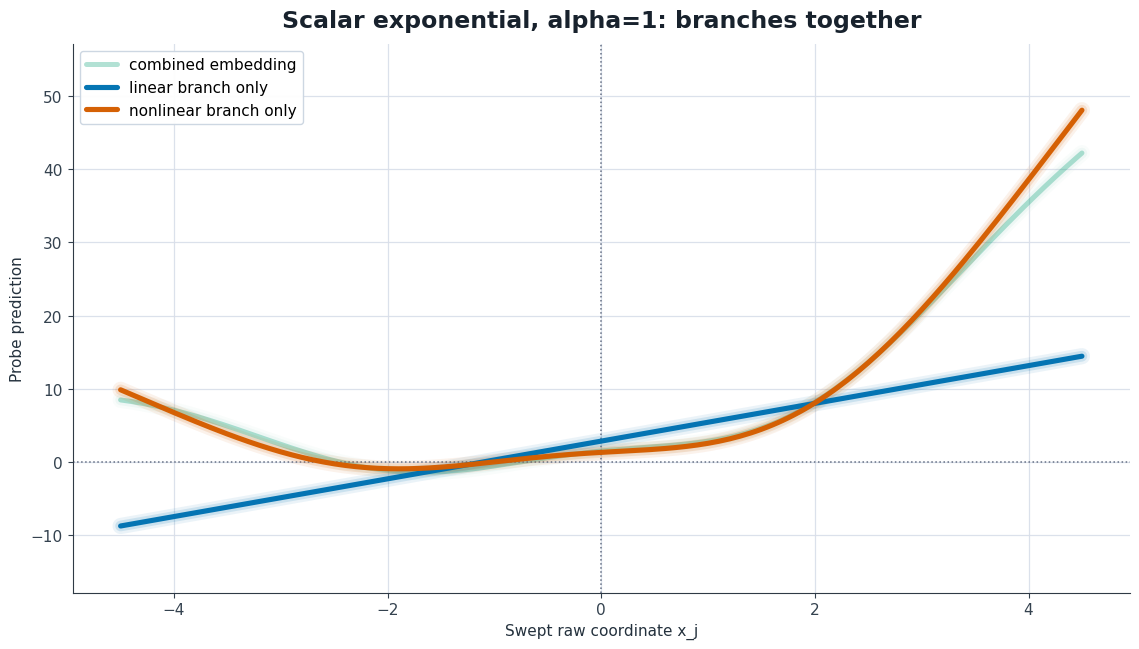

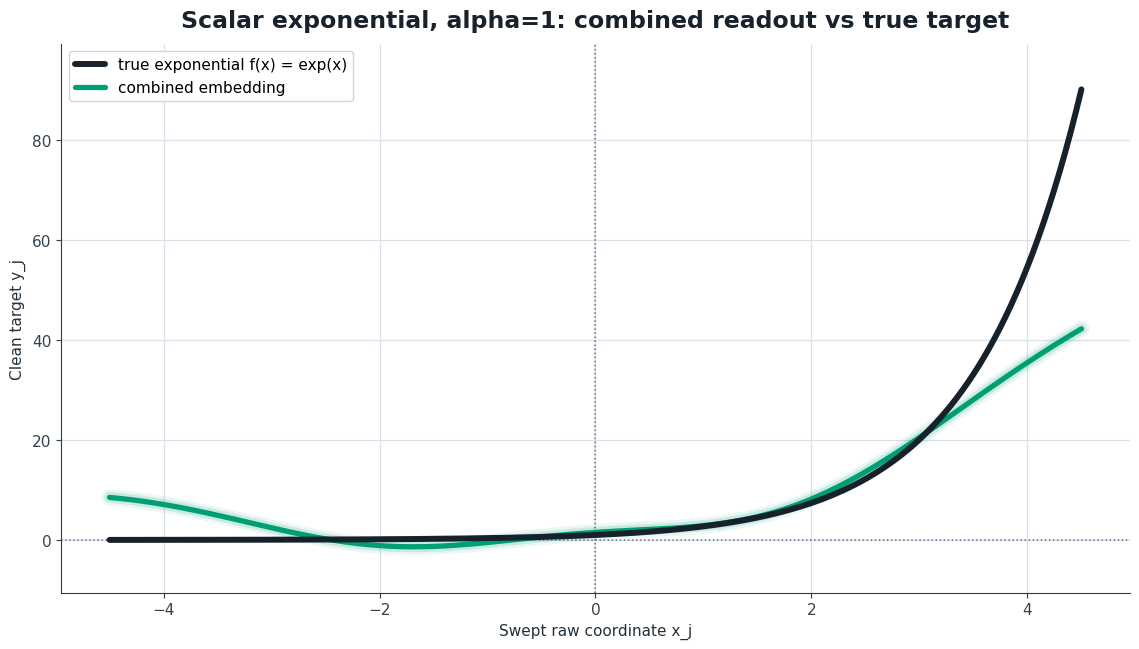

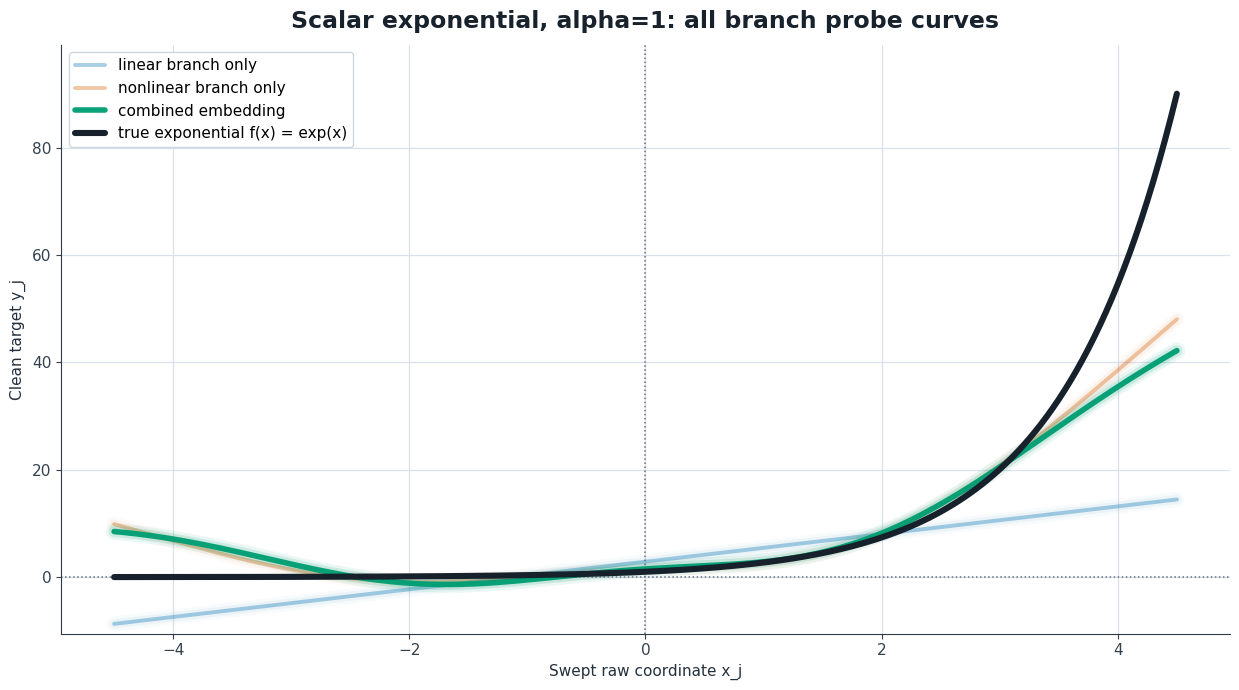

In [43]:
exponential_sweep = np.linspace(-3 * X_STD, 3 * X_STD, 181)

exponential_branch_curves = branch_only_probe_curve(
    run=exponential_run,
    raw_dataset=exponential_dataset,
    relationship=EXPONENTIAL_RELATIONSHIP,
    coordinate=0,
    sweep_values=exponential_sweep,
)

exponential_branch_story_figures = plot_branch_probe_story(
    exponential_branch_curves,
    title_prefix="Scalar exponential, alpha=1",
    filename_prefix=f"alpha1-scalar-{EXPONENTIAL_RELATIONSHIP}-branch-probe-story",
    target_label="true exponential f(x) = exp(x)",
)


## What This Notebook Is Testing

This notebook is a controlled scalar sanity check for the contrastive encoder. Each training example is a paired observation:

```text
(x_i, y_i)
```

where:

- `x_i` is the input-side view with dimension `p`
- `y_i` is the target-side view with dimension `q`

In all experiments in this notebook we intentionally use:

```python
p = 1
q = 1
```

So each example is just one scalar input and one scalar target:

```text
x = [one number]
y = [one number]
```

This is much simpler than the high-dimensional experiments. The point is that, because `p=q=1`, we can sweep the raw scalar `x`, plot the true function `f(x)`, and visually inspect what the learned encoder branches contain.

### Experiment Sets

The notebook runs three scalar deterministic relationships:

| section | `relationship` value | clean target |
|---|---:|---:|
| Cubic | `"cubic"` | `y = x^3` |
| Square / quadratic | `"quadratic"` | `y = x^2` |
| Exponential | `"exponential"` | `y = exp(x)` |

For each relation, the dataset generator samples random scalar inputs and then creates a noisy paired target:

```text
x ~ Normal(0, X_STD^2)
y = f(x) + small Gaussian noise
```

The clean target `f(x)` is also saved, so the plots can compare the learned readout against the true function.

The shared settings are:

```python
n_train = 256
n_test = 512
p = 1
q = 1
TARGET_SNR = 20.0
X_STD = 1.5
EPOCHS = 300
embedding_dim = 4
hidden_dim = 16
```

### Model Setting: Alpha = 1

All three relations use the same residual nonlinear encoder configuration:

```python
alpha1_config = TrainConfig(
    architecture="residual",
    nonlinear_scale=1.0,
    embedding_dim=4,
    hidden_dim=16,
    epochs=300,
)
```

Here `nonlinear_scale=1.0` is the alpha value. Conceptually, the X-side residual encoder has two branches:

```text
encoder_x(x) = linear_branch(x) + alpha * nonlinear_branch(x)
```

Since `alpha = 1`, the nonlinear branch is not being artificially shrunk. The linear and nonlinear parts are allowed to contribute at comparable scale to the final combined embedding.


### Pipeline Structure

The full workflow in this notebook is:

```text
paired scalar data: (X, Y)
        ↓
X is generated first, then Y = f(X) + noise
        ↓
train contrastive model using both X and Y views
        ↓
encoder_x learns: X -> X embedding
encoder_y learns: Y -> Y embedding
        ↓
contrastive loss makes matched X/Y embeddings similar
and mismatched X/Y embeddings less similar
        ↓
after training, freeze the model
        ↓
extract X-side embeddings only
        ↓
split X embedding into:
    linear branch only
    nonlinear branch only
    combined embedding
        ↓
fit ridge probes:
    X branch embedding -> clean Y target
        ↓
sweep raw scalar x over a grid
        ↓
plot predicted Y readout vs true clean Y = f(x)
```

A slightly more concrete version is:

```text
raw x
  -> encoder_x
  -> learned representation z_x
  -> ridge probe fitted after training
  -> predicted clean y
```

During contrastive training, the model sees both sides of the pair:

```text
X batch -> encoder_x -> Z_x
Y batch -> encoder_y -> Z_y
```

The training objective compares `Z_x` and `Z_y`. It is not directly minimizing a supervised regression loss like:

```text
fhat(x) should equal y
```

The ridge probe is added only after training. That is why the probe should be read as an interpretability diagnostic, not as the original training objective.

For the branch plots, the important question is:

```text
If I only give the probe the linear branch, what shape can it recover?
If I only give the probe the nonlinear branch, what shape can it recover?
If I give the probe the combined embedding, how close is it to the true f(x)?
```

So the plots are not showing raw model outputs. They are showing what information about the clean target is linearly readable from each learned representation.

### Why We Separate The Branches

The model itself is trained contrastively: it learns embeddings for paired `x` and `y` views. It does not directly train a plotted function `fhat(x)`.

After training, we freeze the encoder and inspect the learned X-side embedding with ridge probes. A ridge probe is just a simple linear readout:

```text
embedding -> predicted clean y
```

The probe is diagnostic. It asks:

```text
Can the clean target f(x) be recovered from this learned representation?
```

For each relation, the notebook fits branch-only probes for:

```text
linear branch only
nonlinear branch only
combined embedding
```

Then it sweeps scalar `x` over a grid and plots what each readout predicts.

### How To Read The Plots

The first plot for each relation shows:

```text
linear branch only       strong blue
nonlinear branch only    strong orange
combined embedding       faded green
```

This is meant to show what the two branches separately make available to a simple readout, with the combined embedding shown as context.

The second plot compares:

```text
combined embedding readout vs true target f(x)
```

This is the most direct check of whether the final embedding contains enough information to reconstruct the clean function.

The third plot overlays all four curves:

```text
true target
combined embedding
linear branch only
nonlinear branch only
```

In that plot, the true target and combined embedding are emphasized, while the separate branch readouts are more transparent.

### Interpretation

For `y = x^2`, a purely linear function of raw `x` cannot naturally produce a parabola, so we expect the nonlinear branch to be important.

For `y = x^3`, the linear branch can capture the rough increasing trend, but the nonlinear branch should help with curvature.

For `y = exp(x)`, the function is asymmetric and grows quickly on the positive side, so the combined embedding may match the center better than the far positive tail.

The big-picture question is:

```text
Does the nonlinear branch actually carry nonlinear information that is not present in the linear branch alone?
```

This notebook gives a visual way to answer that question before moving back to harder high-dimensional settings.
